# 01. Big Data Concepts & Distributed Computing Theory

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 02, whose complexity analysis asked how an algorithm scales; this lesson asks the same question about the machine, and Course 05 — Unit 2, lesson 01, whose chunked loading was the first symptom.

**Used later in:** Course 05 — Unit 5, lessons 02-04, which are Dask, PySpark and RAPIDS implementations of exactly these ideas.

## Overview

- Big Data characteristics (4 Vs)
- Big Data technologies and challenges
- Distributed systems, parallel computing, and MapReduce
- Fault tolerance

These concepts underpin Dask, PySpark, and RAPIDS workflows covered in later examples.


## 🎯 The case: a 2001 memo, and 100 TB sorted in 23 minutes

The vocabulary you are about to learn has a documented origin. In **2001** the META Group
analyst **Doug Laney** published a research note titled *"3D Data Management: Controlling
Data Volume, Velocity and Variety"*. It was not about Hadoop or clusters — it was about
e-commerce and merger activity forcing companies to think about how data was managed. Those
three words became the "3 Vs", and everything since (veracity, value, and the rest) is a
gloss on that memo.

The engineering answer arrived a decade later. In **November 2014** Databricks entered
Apache Spark in the **Daytona GraySort** benchmark and sorted **100 TB in 23 minutes on 206
EC2 nodes** (6,592 virtualised cores). The previous record, held by Hadoop MapReduce, was
**102.5 TB in 72 minutes on 2,100 machines** with 50,400 physical cores. Three times faster
on **ten times fewer machines** — and the sort ran on disk through HDFS, without Spark's
in-memory caching.

**What goes wrong without these ideas.** Every technique in Units 1 to 4 assumed the table
fits in one machine's memory and one process's patience. When it does not, you do not need
cleverer pandas; you need a different **shape** of computation. You are about to write
MapReduce by hand over 50,000 real 911 records and get **exactly** the same answer as
`value_counts()` — because the arithmetic is unchanged. What changes is that the map phase
touched each record independently, so the same code runs on one machine or a thousand.


## 1. Big Data: The Four Vs

**Volume** – Scale of data (TB, PB). Traditional single-machine tools (e.g. pandas on one laptop) cannot store or process it.

**Variety** – Mixed types: structured (tables), semi-structured (JSON, logs), unstructured (text, images, video). Different storage and processing needs.

**Velocity** – Speed of data generation and ingestion (streaming, real-time). Batch processing alone is insufficient.

**Veracity** – Quality, completeness, and trustworthiness. Big data often includes noise, missing values, and inconsistencies.

## The Story

**BEFORE**: You can work with small datasets but don't understand challenges of big data.

**AFTER**: You'll understand big data concepts: volume, velocity, variety, and strategies for handling large-scale data!

**Why this matters**: Big Data Concepts & Distributed Computing Theory is essential for building complete, professional data science solutions!

---

## 2. Big Data Technologies & Challenges

**Technologies:** Distributed storage (HDFS, S3), distributed processing (Apache Spark, Dask), message queues (Kafka), GPU acceleration (RAPIDS).

**Challenges:**
- Cost and complexity of distributed clusters
- Data locality and network bottlenecks
- Consistency, security, and governance at scale

## 3. Distributed Computing: MapReduce & Parallel Processing

**MapReduce** is a programming model for processing large datasets in parallel:
- **Map:** Apply a function to each partition; produce key–value pairs.
- **Shuffle:** Group by key.
- **Reduce:** Aggregate per key.

Spark and Dask implement MapReduce-style operations (e.g. `groupby`, `apply`) over distributed data.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Concepts: the 4 Vs, MapReduce, fault tolerance
- **Real data:** `montgomery_911_calls.csv` — the MapReduce demonstration below
  counts real 911 call categories rather than made-up letters, so the pattern is
  shown doing an actual job.

**Outputs:** What you'll see when you run the cells

- A hand-written map → group → reduce that agrees exactly with `value_counts()`

---


In [1]:
# WHAT: Implement the MapReduce pattern (map to key-value pairs, group, reduce) over real 911 call records.
# WHY: Seeing the pattern demystifies how clusters count billions of records - each phase
#      parallelizes naturally, and here we check the hand-written version against pandas.

# Conceptual MapReduce-style pattern (single-machine illustration)
from collections import defaultdict
import pandas as pd

DATA_DIR = '../../../Course 04/datasets/raw/'

# Real input: the first 50,000 rows of the Montgomery County 911 dispatch log.
# Each record is a dict, which is exactly the shape a MapReduce job receives.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['title', 'twp'], nrows=50_000)
calls['category'] = calls['title'].str.split(':').str[0]
data = calls[['category', 'twp']].to_dict('records')
print(f"Input: {len(data):,} real 911 call records")

def map_fn(item):
    """Map: emit (category, 1) for each record."""
    category = item.get("category", "unknown")
    return (category, 1)

def reduce_fn(key, values):
    """Reduce: sum counts per key."""
    return (key, sum(values))

# MAP phase - embarrassingly parallel: every record is independent
mapped = [map_fn(d) for d in data]

# SHUFFLE phase - group by key (a real cluster moves data across the network here)
groups = defaultdict(list)
for k, v in mapped:
    groups[k].append(v)

# REDUCE phase - one worker per key
reduced = [reduce_fn(k, vals) for k, vals in groups.items()]
result = dict(sorted(reduced, key=lambda kv: -kv[1]))
print("MapReduce-style (key, count):", result)

# Check the hand-written job against pandas - they must agree exactly
expected = calls['category'].value_counts().to_dict()
print("pandas value_counts():      ", expected)
print(f"Identical: {result == expected}")
print(f"\n💡 The map phase touched {len(data):,} records independently. That is why the")
print("   pattern scales: split the input across 1,000 machines and only the shuffle")
print("   phase needs the network. The arithmetic is unchanged.")

Input: 50,000 real 911 call records
MapReduce-style (key, count): {'EMS': 24479, 'Traffic': 18099, 'Fire': 7422}
pandas value_counts():       {'EMS': 24479, 'Traffic': 18099, 'Fire': 7422}
Identical: True

💡 The map phase touched 50,000 records independently. That is why the
   pattern scales: split the input across 1,000 machines and only the shuffle
   phase needs the network. The arithmetic is unchanged.


Partial counts produced by the MAP phase, one row per partition:
partition       rows       EMS   Traffic      Fire
machine 1     12,500     6,219     4,514     1,767
machine 2     12,500     5,719     4,994     1,787
machine 3     12,500     6,119     4,359     2,022
machine 4     12,500     6,422     4,232     1,846
REDUCE sum    50,000    24,479    18,099     7,422


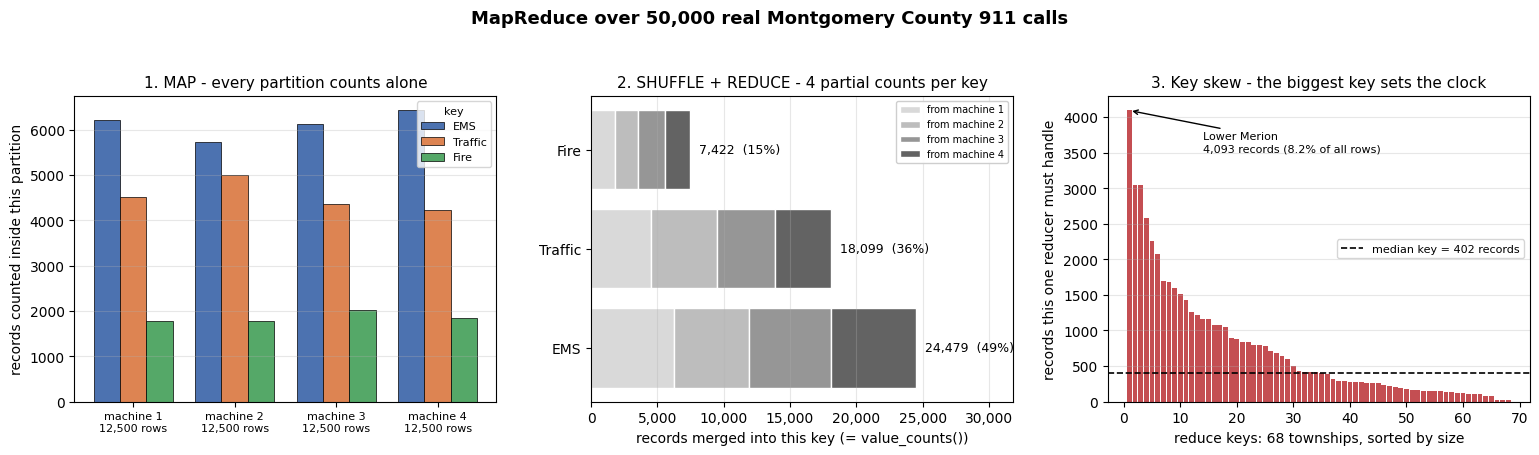


Skew factor if we key by township: biggest key 4,093 records = 10.2x the median key (402).
A single key cannot be split across machines, so that reducer finishes last
while the others idle. Map scales with machines; the shuffle scales with skew.


In [2]:
# WHAT: Draw the three MapReduce phases on the SAME 50,000 real 911 records we just counted.
# WHY: MapReduce is a process, not a number, so a storyboard teaches it better than a table.
#      Panel 1 = the map phase working partition-by-partition, panel 2 = those partial counts
#      merging into the final answer, panel 3 = the one thing that actually breaks real jobs.
import matplotlib.pyplot as plt
import numpy as np

N_PARTITIONS = 4  # pretend the 50,000 records are stored on 4 machines
# Split by row position (no reordering) - this is exactly what a cluster does to a file.
bounds = np.array_split(np.arange(len(calls)), N_PARTITIONS)
parts = [calls.iloc[b] for b in bounds]
cats = ['EMS', 'Traffic', 'Fire']

# MAP: each partition counts only its own rows. No partition looks at any other.
partial = np.array([[int((p['category'] == c).sum()) for c in cats] for p in parts])
# REDUCE: add the partial counts column-wise. That addition is the entire merge step.
totals = partial.sum(axis=0)
assert dict(zip(cats, totals)) == {k: expected[k] for k in cats}, "partial counts must re-sum to the pandas answer"

# The printed step table behind the picture (frame 1 -> frame 2 of the storyboard)
print("Partial counts produced by the MAP phase, one row per partition:")
print(f"{'partition':<12}{'rows':>8}" + "".join(f"{c:>10}" for c in cats))
for i, (p, row) in enumerate(zip(parts, partial), start=1):
    print(f"{'machine ' + str(i):<12}{len(p):>8,}" + "".join(f"{v:>10,}" for v in row))
print(f"{'REDUCE sum':<12}{len(calls):>8,}" + "".join(f"{v:>10,}" for v in totals))

# SKEW: re-run the same job with township as the key instead of category.
twp_counts = calls['twp'].value_counts()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 4.6))

# --- Panel 1: MAP -------------------------------------------------------------
x = np.arange(N_PARTITIONS)
w = 0.26
colors = ['#4C72B0', '#DD8452', '#55A868']
for j, c in enumerate(cats):
    ax1.bar(x + (j - 1) * w, partial[:, j], w, label=c, color=colors[j], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f"machine {i+1}\n{len(p):,} rows" for i, p in enumerate(parts)], fontsize=8)
ax1.set_ylabel("records counted inside this partition")
ax1.set_title("1. MAP - every partition counts alone", fontsize=11)
ax1.legend(fontsize=8, title="key", title_fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# --- Panel 2: SHUFFLE + REDUCE ------------------------------------------------
greys = ['#d9d9d9', '#bdbdbd', '#969696', '#636363']
y = np.arange(len(cats))
left = np.zeros(len(cats))
for i in range(N_PARTITIONS):
    ax2.barh(y, partial[i], left=left, color=greys[i], edgecolor='white',
             linewidth=1.0, label=f"from machine {i+1}")
    left += partial[i]
for yi, (c, t) in enumerate(zip(cats, totals)):
    ax2.text(t + 700, yi, f"{t:,}  ({100*t/len(calls):.0f}%)", va='center', fontsize=9)
ax2.set_yticks(y)
ax2.set_yticklabels(cats)
ax2.set_xlim(0, totals.max() * 1.30)
ax2.set_xlabel("records merged into this key (= value_counts())")
ax2.set_title("2. SHUFFLE + REDUCE - 4 partial counts per key", fontsize=11)
ax2.legend(fontsize=7, loc='upper right', framealpha=0.95)
ax2.grid(axis='x', alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# --- Panel 3: why real jobs stall ---------------------------------------------
ranks = np.arange(1, len(twp_counts) + 1)
ax3.bar(ranks, twp_counts.values, color='#C44E52', width=0.85)
med = twp_counts.median()
ax3.axhline(med, ls='--', color='black', lw=1.2,
            label=f"median key = {med:,.0f} records")
ax3.annotate(f"{twp_counts.index[0].title()}\n{twp_counts.iloc[0]:,} records "
             f"({100*twp_counts.iloc[0]/len(calls):.1f}% of all rows)",
             xy=(1, twp_counts.iloc[0]), xytext=(14, twp_counts.iloc[0] * 0.86),
             fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
ax3.set_xlabel(f"reduce keys: {len(twp_counts)} townships, sorted by size")
ax3.set_ylabel("records this one reducer must handle")
ax3.set_title("3. Key skew - the biggest key sets the clock", fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

fig.suptitle("MapReduce over 50,000 real Montgomery County 911 calls", fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(f"\nSkew factor if we key by township: biggest key {twp_counts.iloc[0]:,} records "
      f"= {twp_counts.iloc[0]/med:.1f}x the median key ({med:,.0f}).")
print("A single key cannot be split across machines, so that reducer finishes last")
print("while the others idle. Map scales with machines; the shuffle scales with skew.")

**Read the figure.** *Left (MAP):* four groups of three bars, one group per partition. Every
machine produces the same three keys in the same order — EMS tallest, then Traffic, then Fire —
because each partition counted its own ~12,500 rows without consulting any other. That
independence is the whole reason the map phase scales.

*Middle (SHUFFLE + REDUCE):* each key's bar is built from four grey segments, one contributed by
each machine. Adding the segments gives 24,479 EMS (49%), 18,099 Traffic (36%), 7,422 Fire (15%) —
the same three numbers `value_counts()` printed above, which the `assert` in the cell checks.
Only this middle step needs the network.

*Right (SKEW):* the same job keyed by township instead. The 68 keys are sorted by size and fall
away steeply: the largest, Lower Merion, holds 4,093 records — 8.2% of all rows and **10.2× the
median key** (dashed line, 402). One key cannot be split across machines, so that reducer is
still working when the other 67 have finished. This is why distributed jobs fail on *shape*
rather than on size, and it is exactly the failure the "⚠️ Where this breaks" section below
describes.

## 💬 Discuss

Your hand-written map → group → reduce produced `{'EMS': 24479, 'Traffic': 18099, 'Fire':
7422}` — identical to `value_counts()` on the same 50,000 real 911 records.

1. The map phase is embarrassingly parallel; the shuffle needs the network. Take a
   different question about this log — *"what was the median response category per
   township?"* — and say which phase it breaks, and why medians are harder to distribute
   than counts.
2. Spark beat Hadoop with **10× fewer machines**. Name two costs of a 2,100-machine cluster
   that never appear in a benchmark time, and say which one you think actually drove the
   industry to switch.
3. Laney's memo described a business problem in 2001, before the tools existed. Pick one of
   the four Vs and argue it is the one that most often defeats projects today — not the one
   the tooling was built for.


## 4. Fault Tolerance

In distributed systems, nodes can fail. **Fault tolerance** means the system continues to work:
- **Replication:** Store data on multiple nodes; if one fails, others serve it.
- **Checkpointing:** Save intermediate results so tasks can be re-run after failure.
- **Idempotency:** Re-running a task produces the same result; safe to retry.

Spark and Dask provide fault-tolerant execution; RAPIDS typically assumes reliable GPU hardware.

## Next Steps

- **Example 02:** Dask for distributed computing
- **Example 03:** PySpark for distributed data processing
- **Example 04:** RAPIDS for GPU-accelerated workflows

## ⚠️ Where this breaks

- **Most "big data" is not big.** The 911 log is 663,522 rows; CIC-IDS2017 is 2.3 million
  rows in 708 MB. Both fit comfortably in a laptop's memory, and pandas handles both faster
  than any cluster would. Distributed tooling has a real floor below which it only adds
  latency, cost and failure modes — Unit 5 lesson 02 measures pandas beating Dask by 12×
  on already-loaded data.
- **MapReduce fits a specific shape of problem.** Counts, sums, means and per-key
  aggregates compose across partitions. Medians, global sorts, exact distinct counts,
  iterative algorithms and anything where record *i* depends on record *i−1* need shuffles,
  approximations, or a different model entirely.
- **The shuffle is where distributed jobs die.** Map scales linearly with machines; the
  shuffle moves data across the network and scales with *how badly your keys are skewed*.
  One township with 40% of the calls means one machine doing 40% of the reduce while the
  rest idle.
- **Fault tolerance is not free.** Replication multiplies storage; checkpointing costs I/O;
  idempotency constrains how you write your code. You buy resilience with throughput, and
  on a job that takes four minutes you have bought nothing.
- **The assumption that must hold: the work decomposes and the network is not the
  bottleneck.** When the data is small enough to fit on one machine, that assumption is
  irrelevant — and the honest engineering answer is a bigger machine, not more of them.
  Cloud instances now reach terabytes of RAM.
- **Cheaper alternative, in order:** read fewer columns; convert to Parquet; use a single
  machine with more memory; use DuckDB, which runs SQL over larger-than-memory files on one
  machine; *then* reach for Dask or Spark. Every step in that list is cheaper to build,
  cheaper to debug, and cheaper to run than the one after it.


## 🔭 State of the field (2026)

The threshold at which "big data" begins has moved up, and it keeps moving. A 2025 EDBT evaluation
of dataframe libraries on real preparation workloads (Mozzillo et al., 2025) reports pandas as the
best choice for small data, Polars once the data fits in RAM, cuDF when a GPU is available, and
PySpark only for data that fits in neither — that last clause is now where a cluster earns its
cost. Storage moved with it: raw files on HDFS gave way to lakehouse table formats — Delta, Iceberg
and Hudi over Parquet — which add ACID transactions and schema enforcement to the same object
storage (Eswararaj et al., 2025, arXiv:2508.13396).

Keep MapReduce anyway. Spark, Dask, Polars and cuDF are all implementing map → shuffle → reduce
underneath, which is why the hand-written version below returns *exactly* what `value_counts()`
returns, and why partitioning, data locality and fault tolerance still explain your job's runtime
on any of them. This unit teaches the shape of distributed computation, which is what the official
plan examines; what 2026 adds is that you should pick the engine on measured evidence rather than
on the word "big".


## 📚 References

1. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>
2. Zaharia, M., Xin, R. S., Wendell, P., et al. (2016). *Apache Spark: A Unified Engine for Big Data Processing*. Communications of the ACM, 59(11), 56-65. <https://doi.org/10.1145/2934664>
3. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
4. Eswararaj, D., Nellipudi, A. B., & Kollati, V. (2025). *A Comparative Study of Delta Parquet, Iceberg, and Hudi for Automotive Data Engineering Use Cases*. arXiv:2508.13396. <https://arxiv.org/abs/2508.13396>
